In [64]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score, KFold

In [65]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [66]:
train_df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [67]:
test_df.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


In [68]:
# Preenchendo valores nulos em Age com a média
train_df['Age'].fillna(train_df['Age'].mean(), inplace=True)
test_df['Age'].fillna(test_df['Age'].mean(), inplace=True)
test_df['Fare'].fillna(test_df['Fare'].mean(), inplace=True)

# Transformando colunas categóricas em binária
train_df['Sex'] = train_df['Sex'].map({'female': 0, 'male': 1})
test_df['Sex'] = test_df['Sex'].map({'female': 0, 'male': 1})

# One-Hot Encoding para Embarked
train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked')
test_df = pd.get_dummies(test_df, columns=['Embarked'], prefix='Embarked')


# Para a variável 'Cabin', foi criado uma variável para dizer se a cabine é conhecida ou não.
train_df['Cabin_known'] = train_df['Cabin'].notna().astype(int)
test_df['Cabin_known'] = test_df['Cabin'].notna().astype(int)
train_df.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'], inplace=True)
test_df.drop(columns=['Cabin'], inplace=True)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Sex          891 non-null    int64  
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
 7   Embarked_C   891 non-null    bool   
 8   Embarked_Q   891 non-null    bool   
 9   Embarked_S   891 non-null    bool   
 10  Cabin_known  891 non-null    int64  
dtypes: bool(3), float64(2), int64(6)
memory usage: 58.4 KB


C:\Users\kleyt\AppData\Local\Temp\ipykernel_25572\3294769396.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].mean(), inplace=True)
C:\Users\kleyt\AppData\Local\Temp\ipykernel_25572\3294769396.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

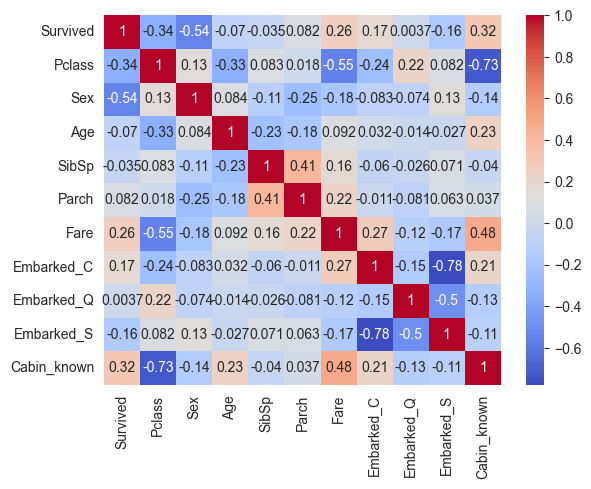

In [69]:
# Heatmap para ver relação das variáveis
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [70]:
# Separando variável target
variables = ['Sex', 'Cabin_known','Fare','Pclass']
x = train_df[variables]
y = train_df['Survived']

x_test = test_df[variables]

# Padronizando variáveis
scaler = StandardScaler()
x = scaler.fit_transform(x)
x_test_scaled = scaler.fit_transform(x_test)

# Balanceado variáveis
smote = SMOTE(random_state=50)
x_balanced, y_balanced = smote.fit_resample(x, y)

In [71]:
# Validação cruzada
folds = 5
cross_validation = KFold(n_splits=folds, shuffle=True, random_state=5)

In [ ]:
# Para utilizar GridSearchCV fui adicionando parâmetros aos poucos até achar a melhor pontuação do cross validation.

In [72]:
# Testando modelo xgboost
# xgboost_model = xgb.XGBClassifier(random_state=50)
#
# xgb_default = cross_val_score(xgboost_model, x_balanced, y_balanced, cv=cross_validation)
#
# xgb_grid = {
#     'n_estimators': [140],
#     'max_depth': [12],
#     'learning_rate': [0.05],
#     'subsample': [0.7],
#     'colsample_bytree': [ 0.8],
#     'gamma': [0],
#     'min_child_weight': [1],
#     'booster': ['gbtree'],
#     'lambda': [1],
#     'alpha': [0],
# }
#
# grid_search_xgb = GridSearchCV(xgboost_model, xgb_grid, cv=5, scoring='accuracy', n_jobs=-1)
#
# grid_search_xgb.fit(x_balanced, y_balanced)
# best_params_xgb = grid_search_xgb.best_params_
# print(f"Melhores parâmetros xgb: {best_params_xgb}")
#
# best_model_xgb = grid_search_xgb.best_estimator_
#
# xgb_best = cross_val_score(best_model_xgb, x_balanced, y_balanced, cv=cross_validation)
#
# print("Pontuações xgb_default: ")
# print(xgb_default.mean())
# print("Pontuações xgb_best: ")
# print(xgb_best.mean())

In [73]:
# Testando modelo SVM
svm_model = SVC(random_state = 50)

svm_default = cross_val_score(svm_model, x_balanced, y_balanced, cv=cross_validation)

svm_grid = {
'C': [100],
'kernel': ['rbf'],
'gamma': ['auto'],
'max_iter': [-1],
'decision_function_shape': ['ovo']
}

grid_search_svm = GridSearchCV(svm_model, svm_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search_svm.fit(x_balanced, y_balanced)
best_params_svm = grid_search_svm.best_params_
print(f"Melhores parâmetros svm: {best_params_svm}")

best_model_svm = grid_search_svm.best_estimator_

svm_best = cross_val_score(best_model_svm, x_balanced, y_balanced, cv=cross_validation)

print("Pontuações svm_default: ")
print(svm_default.mean())
print("Pontuações svm_best: ")
print(svm_best.mean())

Melhores parâmetros svm: {'C': 100, 'decision_function_shape': 'ovo', 'gamma': 'auto', 'kernel': 'rbf', 'max_iter': -1}
Pontuações svm_default: 
0.7850311332503113
Pontuações svm_best: 
0.7950435865504358


In [74]:
# Testando modelo random forest
# rf_model = RandomForestClassifier(random_state=50)
#
# forest_default = cross_val_score(rf_model, x_balanced, y_balanced, cv=cross_validation)
#
# forest_grid = {
#     'n_estimators': [40],
#     'max_depth': [None],
#     'min_samples_split': [6],
#     'min_samples_leaf': [2],
#     'max_features': ['sqrt'],
#     'criterion': ['gini'],
#     'min_weight_fraction_leaf': [0.0],
#     'max_leaf_nodes': [None],
#     'min_impurity_decrease': [0.0]
# }
#
# grid_search_forest = GridSearchCV(rf_model, forest_grid, cv=5, scoring='accuracy', n_jobs=-1)
#
# grid_search_forest.fit(x_balanced, y_balanced)
# best_params_forest = grid_search_forest.best_params_
# print(f"Melhores parâmetros forest: {best_params_forest}")
#
# best_model_forest = grid_search_forest.best_estimator_
#
# forest_best = cross_val_score(best_model_forest, x_balanced, y_balanced, cv=cross_validation)
#
# print("Pontuações forest_default: ")
# print(forest_default.mean())
# print("Pontuações forest_best: ")
# print(forest_best.mean())

In [75]:
# Predição do modelo
predict_test = best_model_svm.predict(x_test_scaled)
predict_test

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,

In [76]:
# Criando csv para envio
toSend = pd.Series(predict_test, index=test_df['PassengerId'], name ='Survived')
toSend.to_csv("titanic_svm.csv" , header=True)

# floresta teve a melhor pontuação por cross validation, mas quem teve a melhor pontuação no site foi svm.